In [1]:
from transformers import AutoProcessor, PaliGemmaForConditionalGeneration
from PIL import Image
import datasets
import torch
import os

/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
hf_token = os.environ["HF_TOKEN"]
gemini_api_key = os.environ["GEMINI_API_KEY"]

In [3]:
model_id = "google/paligemma-3b-mix-448"
model = PaliGemmaForConditionalGeneration.from_pretrained(
    model_id,
    torch_dtype=torch.bfloat16,
    device_map="cuda:0",
    revision="bfloat16",
    token=hf_token
).eval()
processor = AutoProcessor.from_pretrained(model_id)

`config.hidden_act` is ignored, you should use `config.hidden_activation` instead.
Gemma's activation function will be set to `gelu_pytorch_tanh`. Please, use
`config.hidden_activation` if you want to override this behaviour.
See https://github.com/huggingface/transformers/pull/29402 for more details.
Loading checkpoint shards: 100%|██████████| 2/2 [00:05<00:00,  2.73s/it]


In [4]:
dataset = datasets.load_dataset(
    "armaggheddon97/lego_minifigure_captions",
    split="minifigures",
    streaming=True
)

In [8]:
def caption(rows: list):
    prompt = (
       "Describe the LEGO minifigure briefly, focusing on its clothes, "
       "accessories, and theme."
    )
    captions = []

    for row in rows:
        model_inputs = processor(
            text=prompt,
            images=row["image"],
            return_tensors="pt"
        ).to(dtype=torch.bfloat16, device=model.device)
        input_len = model_inputs["input_ids"].shape[-1]
        with torch.inference_mode():
            generation = model.generate(
                **model_inputs,
                max_new_tokens=512,
                do_sample=False
            )
            generation = generation[0][input_len:]
            decoded = processor.decode(generation, skip_special_tokens=True)
            captions.append(decoded)
    return captions


In [9]:
ds_iter = iter(dataset)
rows = [next(ds_iter) for _ in range(10)]
captions = caption(rows)

You are passing both `text` and `images` to `PaliGemmaProcessor`. The processor expects special image tokens in the text, as many tokens as there are images per each text. It is recommended to add `<image>` tokens in the very beginning of your text and `<bos>` token after that. For this call, we will infer how many images each text has and add special tokens.
You are passing both `text` and `images` to `PaliGemmaProcessor`. The processor expects special image tokens in the text, as many tokens as there are images per each text. It is recommended to add `<image>` tokens in the very beginning of your text and `<bos>` token after that. For this call, we will infer how many images each text has and add special tokens.
You are passing both `text` and `images` to `PaliGemmaProcessor`. The processor expects special image tokens in the text, as many tokens as there are images per each text. It is recommended to add `<image>` tokens in the very beginning of your text and `<bos>` token after tha

In [10]:
captions

['the lego minifigure has a yellow shirt with a red and black logo, brown pants, and red hair.',
 'the lego minifigure has a red jacket, blue pants, and brown hair.',
 'The minifigure is a white robot with an orange light on its head.',
 'the lego minifigure has brown hair, black pants, and a white shirt.',
 'a lego minifigure with a blue suit and a star on it',
 'the lego minifigure has a green shirt and green pants.',
 'the lego minifigure is a green one with a white helmet and green and yellow clothes.',
 'the lego minifigure is a woman with long black hair and a red top with a silver symbol on it.',
 'the flash',
 'the lego minifigure is batman with a black cape and grey armour.']

In [11]:
from IPython.display import display
from matplotlib import pyplot as plt

/tmp/ipykernel_138057/3785566483.py:10: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


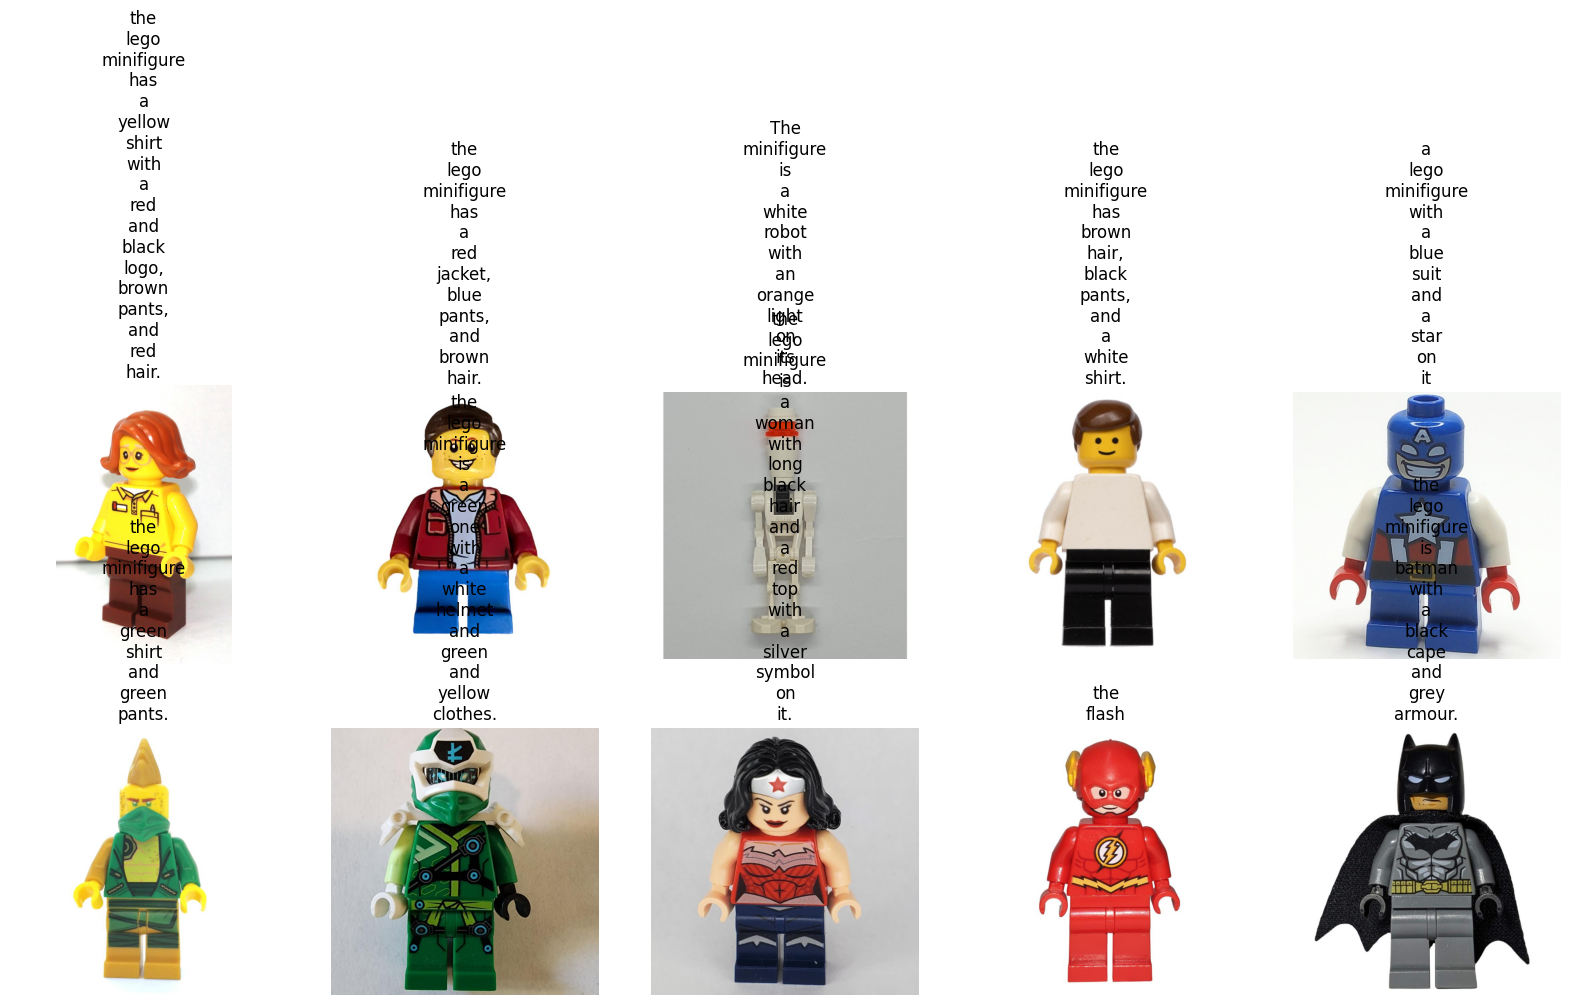

In [12]:
# show a 2x5 grid of images with the respective captions on top 
# if the caption is too long, split it across multiple lines
fig, axs = plt.subplots(2, 5, figsize=(20, 8))
for i, row in enumerate(rows):
    ax = axs[i // 5, i % 5]
    ax.imshow(row["image"])
    ax.axis("off")
    ax.set_title("\n".join(captions[i].split()), fontsize=12)

plt.tight_layout()



In [13]:
import google.generativeai as genai

In [14]:
genai.configure(api_key=gemini_api_key)
gemini_flash = genai.GenerativeModel("gemini-1.5-flash")

In [15]:
prompt = "You are a precise and detailed image captioning assistant. Your task is to describe LEGO minifigures in a single sentence, focusing on their unique features, such as attire, accessories, facial expression, and theme. Avoid generic terms and aim for specificity, while remaining concise."
responses = [
    gemini_flash.generate_content([prompt, row["image"]])
    for row in rows
]

In [16]:
for idx, response in enumerate(responses):
    print(f"[{idx}] {response.text}")

[0] A cheerful LEGO minifigure woman with auburn hair, wearing glasses, a yellow collared shirt with a logo and pen pocket, and dark-brown trousers, suggests a service or office worker theme.

[1] A smiling LEGO minifigure with brown hair, freckles, and a maroon zip-up jacket over a light blue collared shirt, paired with royal blue pants, suggests a casual, possibly everyday, theme.

[2] A white LEGO Star Wars Super Battle Droid minifigure features a distinctive orange-ringed headpiece and lacks a facial expression.

[3] A smiling LEGO minifigure with dark brown hair, wearing an off-white long-sleeved shirt and black trousers, evokes a classic, possibly civilian, theme.

[4] A grinning LEGO Captain America minifigure sports a blue helmet with a prominent "A," a blue torso with a white star and red stripes, off-white sleeves, and red hands, reflecting a classic comic book aesthetic.

[5] A LEGO Ninjago minifigure with a gold spiky headdress, a green bandana, a distressed green jacket ov

/tmp/ipykernel_138057/3689463812.py:10: UserWarning: Tight layout not applied. tight_layout cannot make Axes height small enough to accommodate all Axes decorations.
  plt.tight_layout()


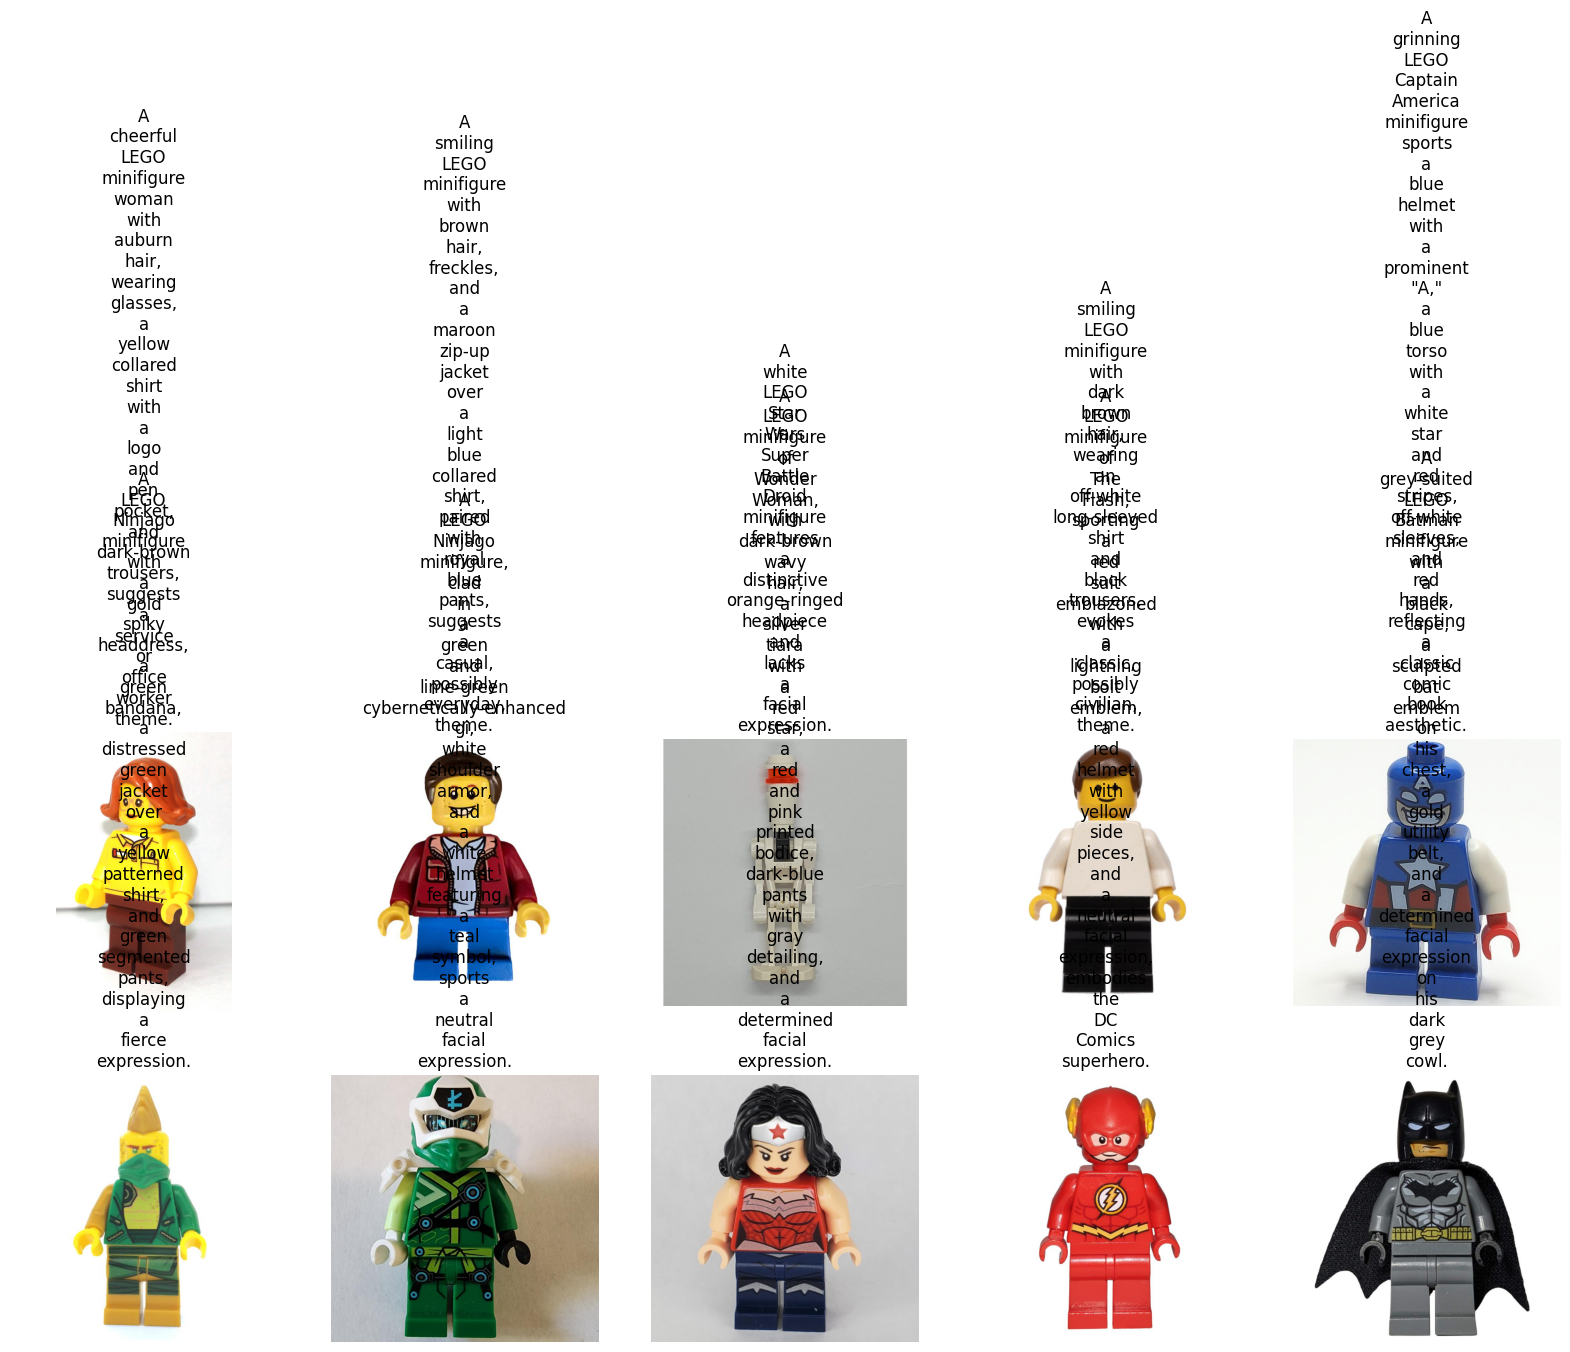

In [17]:
# show a 2x5 grid of images with the respective captions on top 
# if the caption is too long, split it across multiple lines
fig, axs = plt.subplots(2, 5, figsize=(20, 8))
for i, row in enumerate(rows):
    ax = axs[i // 5, i % 5]
    ax.imshow(row["image"])
    ax.axis("off")
    ax.set_title("\n".join(responses[i].text.split()), fontsize=12)

plt.tight_layout()
